In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import os

drive_path = '/content/drive/MyDrive/Car_dent'

# Check if the directory exists
if os.path.exists(drive_path):
    print(f"Listing contents of: {drive_path}")
    for item in os.listdir(drive_path):
        print(item)
else:
    print(f"Directory not found: {drive_path}")
    print("Please ensure the folder name 'Car_dent wale' is correct and it's directly under 'MyDrive'.")

Listing contents of: /content/drive/MyDrive/Car_dent
README.dataset.txt
data.yaml
test
train
valid


In [11]:
pip install ultralytics

In [12]:
from ultralytics import YOLO
import os

# Define the path to your dataset configuration file
data_yaml_path = os.path.join(drive_path, 'data.yaml')

# Check if data.yaml exists
if not os.path.exists(data_yaml_path):
    print(f"Error: data.yaml not found at {data_yaml_path}. Please ensure the file exists.")
else:
    print(f"Found data.yaml at: {data_yaml_path}")

# Load a pre-trained YOLOv8 instance segmentation model (e.g., yolov8n-seg.pt)
# You can choose other models like yolov8s-seg.pt, yolov8m-seg.pt, etc., based on your needs.
model = YOLO('yolov8n-seg.pt') # Using a nano segmentation model as a starting point

# Define training parameters as requested by the user
epochs = 50
lr = 0.0001
batch_size = 16
workers = 2
optimizer = 'Adam' # YOLOv8 supports Adam, SGD, etc.

print("\nTraining parameters:")
print(f"Epochs: {epochs}")
print(f"Learning Rate: {lr}")
print(f"Batch Size: {batch_size}")
print(f"Workers: {workers}")
print(f"Optimizer: {optimizer}")
print("Note: YOLOv8 internally handles loss function, activation function, and dropout rate based on the model architecture.")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Found data.yaml at: /content/drive/MyDrive/Car_dent/data.yaml

Training parameters:
Epochs: 50
Learning Rate: 0.0001
Batch Size: 16
Workers: 2
Optimizer: Adam
Note: YOLOv8 internally handles loss function, activation function, and dropout rate based on the model architecture.


Now, let's train the model using the specified parameters.

In [13]:
if os.path.exists(data_yaml_path):
    # Train the model
    results = model.train(
        data=data_yaml_path,
        epochs=epochs,
        imgsz=640, # Image size, common for YOLO models
        batch=batch_size,
        lr0=lr, # Initial learning rate
        workers=workers,
        optimizer=optimizer,
        project='yolov8_car_dent_segmentation', # Project name for results
        name='exp_1' # Experiment name
    )
    print("\nModel training completed!")
else:
    print("Cannot train model: data.yaml was not found. Please verify the path.")

Ultralytics 8.4.62 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/Car_dent/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=exp_1, nbs=64, nms=False, opset=None, optimize=False, optimizer=Adam, overlap_mask=T

After training, the results (including metrics, plots, and weights) are typically saved in the `runs/segment/exp_1` directory (or similar, depending on the `name` parameter). Let's generate a classification report and visualize the training/validation graphs.

Results are saved in: /content/runs/segment/yolov8_car_dent_segmentation/exp_1

Generating Classification Report (Validation Metrics):

--- Final Validation Metrics (Last Epoch) ---

--- Bounding Box Detection Metrics ---
Precision (BBox): 0.3872
Recall (BBox): 0.3661
F1-Score (BBox): 0.3763
mAP50 (BBox): 0.2803
mAP50-95 (BBox): 0.1804

--- Segmentation Mask Metrics ---
Precision (Mask): 0.4111
Recall (Mask): 0.3175
F1-Score (Mask): 0.3583
mAP50 (Mask): 0.2378
mAP50-95 (Mask): 0.1251

Generating Training and Validation Graphs...


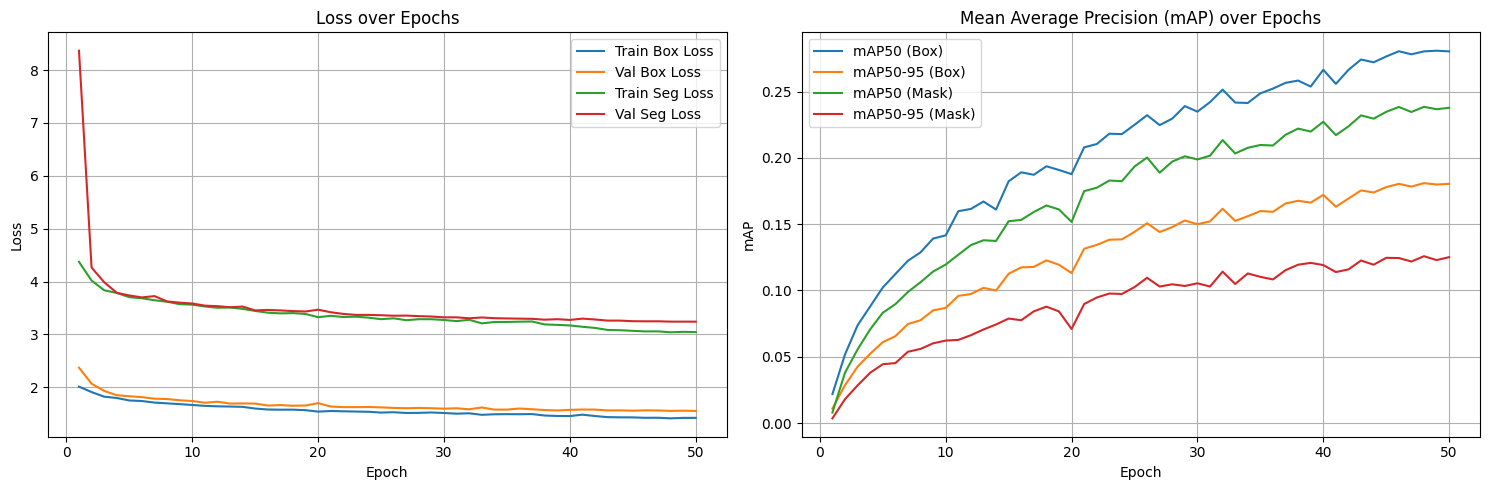

In [16]:
import matplotlib.pyplot as plt
import pandas as pd

# Path to the training results directory (adjust if 'name' was different)
results_dir = os.path.join(model.trainer.save_dir)

print(f"Results are saved in: {results_dir}")

# --- Generate Classification Report (Validation metrics) ---
print("\nGenerating Classification Report (Validation Metrics):")
# The validation metrics are usually available in the 'results.csv' file
metrics_path = os.path.join(results_dir, 'results.csv')

if os.path.exists(metrics_path):
    # Read the results CSV, skipping the first few comment lines
    metrics_df = pd.read_csv(metrics_path)
    # The columns might have leading/trailing spaces due to comments, strip them
    metrics_df.columns = metrics_df.columns.str.strip()

    # Display relevant metrics for the last epoch
    last_epoch_metrics = metrics_df.iloc[-1]

    print("\n--- Final Validation Metrics (Last Epoch) ---")

    # Bounding Box Metrics
    bbox_precision = last_epoch_metrics['metrics/precision(B)']
    bbox_recall = last_epoch_metrics['metrics/recall(B)']
    bbox_f1 = 2 * (bbox_precision * bbox_recall) / (bbox_precision + bbox_recall) if (bbox_precision + bbox_recall) > 0 else 0

    print("\n--- Bounding Box Detection Metrics ---")
    print(f"Precision (BBox): {bbox_precision:.4f}")
    print(f"Recall (BBox): {bbox_recall:.4f}")
    print(f"F1-Score (BBox): {bbox_f1:.4f}")
    print(f"mAP50 (BBox): {last_epoch_metrics['metrics/mAP50(B)']:.4f}")
    print(f"mAP50-95 (BBox): {last_epoch_metrics['metrics/mAP50-95(B)']:.4f}")

    # Segmentation Mask Metrics
    seg_precision = last_epoch_metrics['metrics/precision(M)']
    seg_recall = last_epoch_metrics['metrics/recall(M)']
    seg_f1 = 2 * (seg_precision * seg_recall) / (seg_precision + seg_recall) if (seg_precision + seg_recall) > 0 else 0

    print("\n--- Segmentation Mask Metrics ---")
    print(f"Precision (Mask): {seg_precision:.4f}")
    print(f"Recall (Mask): {seg_recall:.4f}")
    print(f"F1-Score (Mask): {seg_f1:.4f}")
    print(f"mAP50 (Mask): {last_epoch_metrics['metrics/mAP50(M)']:.4f}")
    print(f"mAP50-95 (Mask): {last_epoch_metrics['metrics/mAP50-95(M)']:.4f}")

    # --- Generate Training Graphs ---
    print("\nGenerating Training and Validation Graphs...")

    plt.figure(figsize=(15, 5))

    # Plot Loss
    plt.subplot(1, 2, 1)
    plt.plot(metrics_df['epoch'], metrics_df['train/box_loss'], label='Train Box Loss')
    plt.plot(metrics_df['epoch'], metrics_df['val/box_loss'], label='Val Box Loss')
    plt.plot(metrics_df['epoch'], metrics_df['train/seg_loss'], label='Train Seg Loss')
    plt.plot(metrics_df['epoch'], metrics_df['val/seg_loss'], label='Val Seg Loss')
    plt.title('Loss over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    # Plot mAP
    plt.subplot(1, 2, 2)
    plt.plot(metrics_df['epoch'], metrics_df['metrics/mAP50(B)'], label='mAP50 (Box)')
    plt.plot(metrics_df['epoch'], metrics_df['metrics/mAP50-95(B)'], label='mAP50-95 (Box)')
    plt.plot(metrics_df['epoch'], metrics_df['metrics/mAP50(M)'], label='mAP50 (Mask)')
    plt.plot(metrics_df['epoch'], metrics_df['metrics/mAP50-95(M)'], label='mAP50-95 (Mask)')
    plt.title('Mean Average Precision (mAP) over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('mAP')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()
else:
    print(f"Error: results.csv not found at {metrics_path}. Cannot generate classification report or graphs.")

### Training and Validation Visualizations

YOLOv8 automatically generates several plots during training to visualize performance. Let's display some of the key graphs saved in the results directory.

Looking for plots in: /content/runs/segment/yolov8_car_dent_segmentation/exp_1


<Figure size 1500x1000 with 0 Axes>

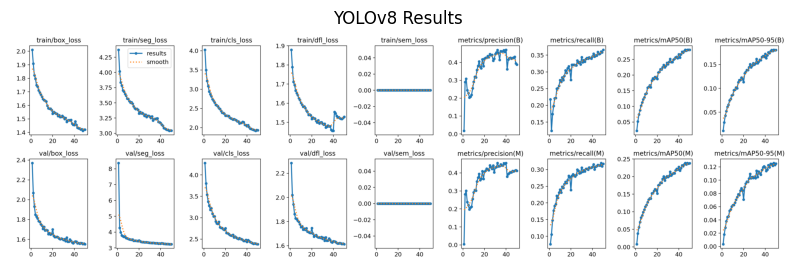

Plot file not found: F1_curve.png
Plot file not found: P_curve.png
Plot file not found: R_curve.png


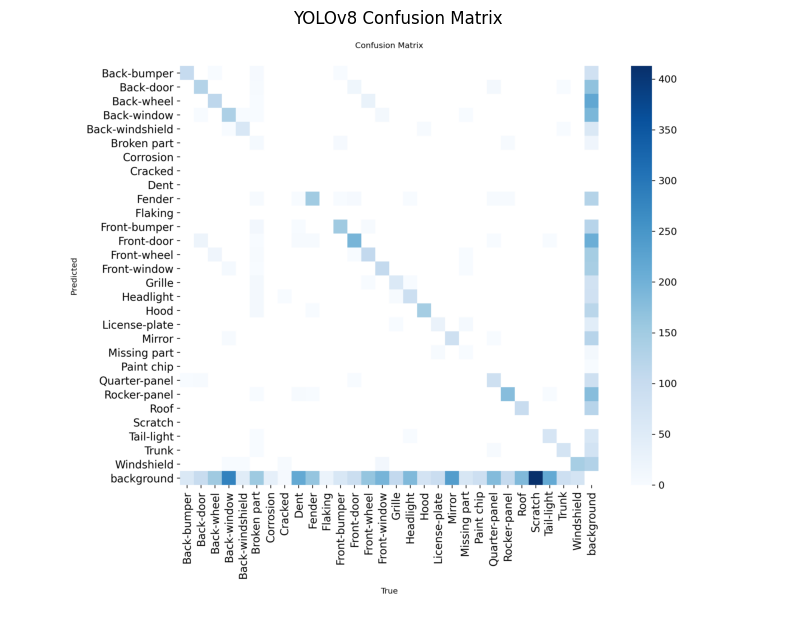

Successfully displayed 2 training and validation plots.


In [38]:
import matplotlib.pyplot as plt
import os

# Ensure results_dir is defined from previous cells
if 'results_dir' not in locals() or results_dir is None:
    # Fallback if the variable is not set (e.g., if the user ran cells out of order)
    results_dir = '/content/runs/segment/yolov8_car_dent_segmentation/exp_1' # Assuming default path

print(f"Looking for plots in: {results_dir}")

plot_files = [
    'results.png',          # Contains training/validation loss and mAP curves
    'F1_curve.png',         # F1-score curve
    'P_curve.png',          # Precision-Confidence curve
    'R_curve.png',          # Recall-Confidence curve
    'confusion_matrix.png'  # Confusion Matrix
]

plt.figure(figsize=(15, 10))

displayed_plots = 0
for i, plot_file in enumerate(plot_files):
    plot_path = os.path.join(results_dir, plot_file)
    if os.path.exists(plot_path):
        try:
            img = plt.imread(plot_path)
            # Determine subplot grid dynamically based on number of plots to show
            # This is a bit tricky with matplotlib. Let's just show them one by one for simplicity
            plt.figure(figsize=(10, 8))
            plt.imshow(img)
            plt.title(f"YOLOv8 {plot_file.replace('.png', '').replace('_', ' ').title()}")
            plt.axis('off')
            plt.show()
            displayed_plots += 1
        except Exception as e:
            print(f"Could not load or display {plot_file}: {e}")
    else:
        print(f"Plot file not found: {plot_file}")

if displayed_plots == 0:
    print("No training/validation plots were found in the results directory.")
else:
    print(f"Successfully displayed {displayed_plots} training and validation plots.")


Finally, let's generate some predictions on the validation set or a sample image to see the model in action.

Loaded best model from: /content/runs/segment/yolov8_car_dent_segmentation/exp_1/weights/best.pt

Generating prediction for sample image: /content/drive/MyDrive/Car_dent/valid/images/Car-damages-1136_png.rf.397dae8e499e2d573e7c283e14fba265.jpg

image 1/1 /content/drive/MyDrive/Car_dent/valid/images/Car-damages-1136_png.rf.397dae8e499e2d573e7c283e14fba265.jpg: 640x640 2 Front-bumpers, 1 Front-wheel, 1 Headlight, 1 Hood, 1 License-plate, 1 Windshield, 10.1ms
Speed: 4.0ms preprocess, 10.1ms inference, 10.6ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/segment/predict
Predicted image saved to: /content/runs/segment/predict/Car-damages-1136_png.rf.397dae8e499e2d573e7c283e14fba265.jpg


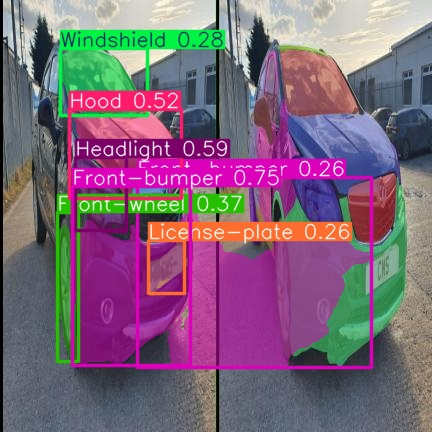


Detected objects and confidence scores:
Class: Front-bumper, Confidence: 0.75
Class: Front-bumper, Confidence: 0.75
Class: Front-bumper, Confidence: 0.75
Class: Front-bumper, Confidence: 0.75
Class: Front-bumper, Confidence: 0.75
Class: Front-bumper, Confidence: 0.75
Class: Front-bumper, Confidence: 0.75


In [15]:
import cv2
from google.colab.patches import cv2_imshow

# Load the best trained model weights
best_model_path = os.path.join(results_dir, 'weights', 'best.pt')
if os.path.exists(best_model_path):
    trained_model = YOLO(best_model_path)
    print(f"Loaded best model from: {best_model_path}")

    # --- Generate Predictions ---
    # You'll need to specify an image for prediction.
    # For demonstration, let's try to find a sample image from the 'test' or 'valid' folder.

    # Assuming the 'valid/images' directory exists inside your drive_path
    valid_images_path = os.path.join(drive_path, 'valid', 'images')
    if os.path.exists(valid_images_path):
        sample_images = [f for f in os.listdir(valid_images_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        if sample_images:
            sample_image_path = os.path.join(valid_images_path, sample_images[0])
            print(f"\nGenerating prediction for sample image: {sample_image_path}")

            # Run inference
            predict_results = trained_model.predict(source=sample_image_path, save=True, conf=0.25, iou=0.7)

            # Display the predicted image (if saved)
            # The predict method saves results to 'runs/segment/predict' or similar
            predicted_image_output_path = os.path.join(trained_model.predictor.save_dir, os.path.basename(sample_image_path))
            if os.path.exists(predicted_image_output_path):
                print(f"Predicted image saved to: {predicted_image_output_path}")
                img = cv2.imread(predicted_image_output_path)
                cv2_imshow(img)
            else:
                print("Could not find the predicted image to display.")

            # Print detected objects and their confidence scores
            print("\nDetected objects and confidence scores:")
            for r in predict_results:
                for box, seg in zip(r.boxes.xyxy, r.masks.xy): # Iterate through detected objects
                    conf = r.boxes.conf[0].item() # Confidence score for the first box (assuming one object for simplicity)
                    class_id = int(r.boxes.cls[0].item()) # Class ID for the first box
                    class_name = trained_model.names[class_id] # Get class name
                    print(f"Class: {class_name}, Confidence: {conf:.2f}")
        else:
            print(f"No image files found in {valid_images_path} to generate predictions.")
    else:
        print(f"Validation image path not found: {valid_images_path}. Cannot generate predictions.")
else:
    print(f"Best trained model weights not found at {best_model_path}. Cannot generate predictions.")

In [17]:
from ultralytics import YOLO

# 1. Apne trained model ko load karein (jo exp_1 folder mein save hua hai)
model_path = '/content/runs/segment/yolov8_car_dent_segmentation/exp_1/weights/best.pt'
model = YOLO(model_path)

print("--- TEST IMAGES PAR DENTS DETECT HO RAHE HAIN ---")

# 2. Test folder ki images par prediction run karein
results = model.predict(
    source='/content/drive/MyDrive/Car_dent/test/images', # Aapke test folder ka path
    conf=0.20,        # Confidence threshold (agar dents miss hon toh isko 0.15 kar dena)
    save=True,        # Visual images par mask aur box save karne ke liye
    show_labels=True, # Dent ka naam aur percentage dikhane ke liye
    show_boxes=True   # Bounding box bhi show karne ke liye
)

print("\n✅ Testing complete! Saari processed images yahan dekhin:")
print("/content/runs/segment/predict/")

--- TEST IMAGES PAR DENTS DETECT HO RAHE HAIN ---

image 1/415 /content/drive/MyDrive/Car_dent/test/images/Car-damages-1034_png.rf.cc9cb22722892cbe5dbd2d3e8212e920.jpg: 640x640 2 Back-doors, 1 Back-wheel, 2 Back-windows, 1 Fender, 1 Front-bumper, 1 Front-door, 1 Front-wheel, 1 Front-window, 1 Headlight, 1 Hood, 1 Mirror, 1 Quarter-panel, 1 Rocker-panel, 2 Roofs, 1 Tail-light, 1 Windshield, 11.1ms
image 2/415 /content/drive/MyDrive/Car_dent/test/images/Car-damages-1035_png.rf.9b2430007a1eca4ce04a6ed75a8da13d.jpg: 640x640 (no detections), 11.5ms
image 3/415 /content/drive/MyDrive/Car_dent/test/images/Car-damages-1046_png.rf.b313833dc70d44c41dfe26c73b625746.jpg: 640x640 2 Back-bumpers, 1 Back-wheel, 2 Back-windshields, 1 Front-door, 1 Front-window, 1 License-plate, 1 Mirror, 1 Rocker-panel, 4 Trunks, 12.2ms
image 4/415 /content/drive/MyDrive/Car_dent/test/images/Car-damages-1047_png.rf.c2392fdebea6f7ec36ab36a083ce44d1.jpg: 640x640 1 Back-bumper, 1 Back-door, 2 Back-wheels, 2 Back-windows,

## Predict on a Custom Image

Now, you can upload any image you want to test and see the model's predictions on it.

Saving Car-damages-11_png.rf.39966fa920750726e535d14201efb1bc.jpg to Car-damages-11_png.rf.39966fa920750726e535d14201efb1bc.jpg

Predicting on uploaded image: Car-damages-11_png.rf.39966fa920750726e535d14201efb1bc.jpg

image 1/1 /content/Car-damages-11_png.rf.39966fa920750726e535d14201efb1bc.jpg: 640x640 1 Back-door, 1 Back-window, 1 Fender, 1 Front-door, 1 Front-wheel, 1 Headlight, 1 Hood, 2 Mirrors, 2 Rocker-panels, 1 Roof, 1 Windshield, 12.2ms
Speed: 3.1ms preprocess, 12.2ms inference, 2.9ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/segment/predict
Predicted image saved to: /content/runs/segment/predict-2/Car-damages-11_png.rf.39966fa920750726e535d14201efb1bc.jpg


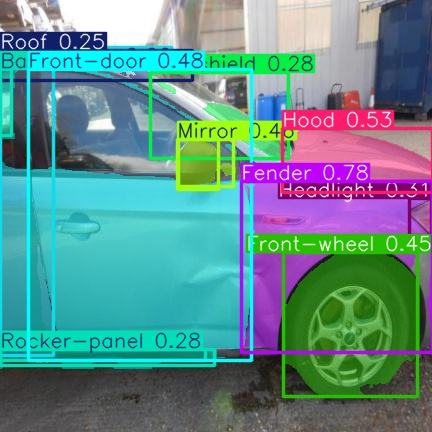


Detected objects on custom image:
  - Class: Fender, Confidence: 0.78
  - Class: Hood, Confidence: 0.53
  - Class: Front-door, Confidence: 0.48
  - Class: Mirror, Confidence: 0.46
  - Class: Front-wheel, Confidence: 0.45
  - Class: Mirror, Confidence: 0.35
  - Class: Headlight, Confidence: 0.31
  - Class: Back-window, Confidence: 0.29
  - Class: Windshield, Confidence: 0.28
  - Class: Rocker-panel, Confidence: 0.28
  - Class: Roof, Confidence: 0.25
  - Class: Rocker-panel, Confidence: 0.24
  - Class: Back-door, Confidence: 0.22


In [18]:
from google.colab import files

# Upload your custom image
uploaded = files.upload()

for fn in uploaded.keys():
    # Save the uploaded file to a temporary path
    uploaded_image_path = os.path.join('/content', fn)
    with open(uploaded_image_path, 'wb') as f:
        f.write(uploaded[fn])

    print(f"\nPredicting on uploaded image: {fn}")

    # Run inference on the uploaded image using the trained_model (from previous cell)
    # Adjust conf threshold if needed
    custom_predict_results = trained_model.predict(
        source=uploaded_image_path,
        conf=0.20,       # Confidence threshold
        iou=0.7,         # IoU threshold for NMS
        save=True,       # Save visual results
        show_labels=True, # Show class labels
        show_boxes=True  # Show bounding boxes
    )

    # Display the predicted image
    # The predict method saves results to a new directory like 'runs/segment/predictN'
    # Find the latest prediction directory
    predict_run_dirs = sorted([d for d in os.listdir('/content/runs/segment') if d.startswith('predict')])
    latest_predict_dir = os.path.join('/content/runs/segment', predict_run_dirs[-1])

    predicted_custom_image_path = os.path.join(latest_predict_dir, fn)

    if os.path.exists(predicted_custom_image_path):
        print(f"Predicted image saved to: {predicted_custom_image_path}")
        img_display = cv2.imread(predicted_custom_image_path)
        cv2_imshow(img_display)
    else:
        print("Could not find the predicted image to display. Check the output directory for logs.")

    # Optionally print detected objects and their confidence scores for the custom image
    print("\nDetected objects on custom image:")
    for r in custom_predict_results:
        if r.boxes and len(r.boxes.conf) > 0:
            for i in range(len(r.boxes.conf)):
                conf_score = r.boxes.conf[i].item()
                class_id = int(r.boxes.cls[i].item())
                class_name = trained_model.names[class_id]
                print(f"  - Class: {class_name}, Confidence: {conf_score:.2f}")
        else:
            print("  No objects detected.")

## Predict on a User-Specified Image Path

If you have an image already available in your Colab environment or Google Drive, you can provide its path directly below to get predictions.

Please enter the path to your image: /content/drive/MyDrive/Car_dent/test/images/Car-damages-1246_png.rf.63e960d963af722ce18735c7d11c0650.jpg

Predicting on user-specified image: /content/drive/MyDrive/Car_dent/test/images/Car-damages-1246_png.rf.63e960d963af722ce18735c7d11c0650.jpg

image 1/1 /content/drive/MyDrive/Car_dent/test/images/Car-damages-1246_png.rf.63e960d963af722ce18735c7d11c0650.jpg: 640x640 1 Back-door, 2 Back-windows, 1 Fender, 2 Front-bumpers, 2 Front-doors, 1 Front-wheel, 1 Front-window, 2 Grilles, 1 Headlight, 1 Hood, 1 Mirror, 1 Rocker-panel, 1 Roof, 1 Windshield, 12.3ms
Speed: 3.0ms preprocess, 12.3ms inference, 3.7ms postprocess per image at shape (1, 3, 640, 640)

Detected objects on custom image:
  - Class: Windshield, Confidence: 0.93 (Damage: False)
  - Class: Hood, Confidence: 0.91 (Damage: False)
  - Class: Front-door, Confidence: 0.82 (Damage: False)
  - Class: Front-wheel, Confidence: 0.75 (Damage: False)
  - Class: Front-window, Confidence: 0.63 (Damage: 

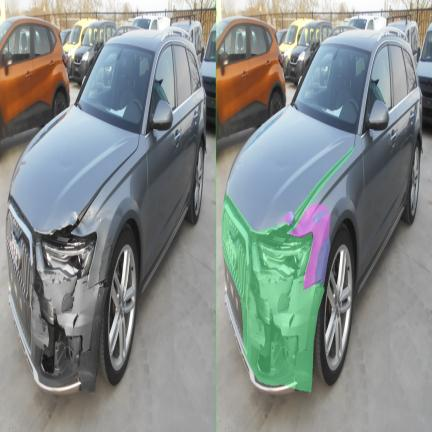

In [37]:
import cv2
from google.colab.patches import cv2_imshow
import os
from ultralytics import YOLO
import numpy as np # Needed for array manipulation

# --- USER INPUT: Specify the path to your image here ---
# You can type or paste the path to your image in the input box that appears.
# Example paths:
# '/content/drive/MyDrive/my_images/my_car_photo.jpg'
# '/content/runs/segment/predict-2/Car-damages-11_png.rf.39966fa920750726e535d14201efb1bc.jpg'

user_image_path = input("Please enter the path to your image: ") # User will be prompted to enter the path

if os.path.exists(user_image_path):
    print(f"\nPredicting on user-specified image: {user_image_path}")

    # Ensure trained_model is loaded (it should be from previous cells, but good practice to check)
    if 'trained_model' not in locals():
        # Fallback for results_dir if not defined in current session
        if 'results_dir' not in locals():
            results_dir = '/content/runs/segment/yolov8_car_dent_segmentation/exp_1'
        best_model_path = os.path.join(results_dir, 'weights', 'best.pt')
        if os.path.exists(best_model_path):
            trained_model = YOLO(best_model_path)
            print(f"Loaded trained model from: {best_model_path}")
        else:
            print("Error: Trained model not found. Please run previous training cells.")
            trained_model = None

    original_image = None
    if trained_model:
        # Load the original image to draw on
        original_image = cv2.imread(user_image_path)
        if original_image is None:
            print(f"Error: Could not load image from {user_image_path}")
            trained_model = None # Prevent further processing if image not loaded

    if trained_model and original_image is not None:
        # Run inference on the specified image, without saving the annotated image by default
        custom_predict_results = trained_model.predict(
            source=user_image_path,
            conf=0.20,       # Confidence threshold
            iou=0.7,         # IoU threshold for NMS
            save=False,      # Do not save annotated image, we will draw custom
            show_labels=False, # We will draw custom labels
            show_boxes=False  # We will draw custom boxes
        )

        # Create a copy of the original image to draw masks on
        annotated_image = original_image.copy()

        # Define color for damage (BGR format)
        DAMAGE_COLOR = (0, 0, 255) # Red for damage
        alpha = 0.5 # Transparency factor

        # Keywords to identify damage classes (case-insensitive)
        damage_keywords = ['dent', 'scratch', 'crack', 'corrosion', 'damage', 'flaking', 'broken', 'chip']

        print("\nDetected objects on custom image:")
        for r in custom_predict_results:
            if r.masks is not None and len(r.masks.xy) > 0:
                for i, mask_polygon_xy in enumerate(r.masks.xy):
                    # Get class ID and name
                    class_id = int(r.boxes.cls[i].item())
                    class_name = trained_model.names[class_id]
                    conf_score = r.boxes.conf[i].item()

                    # Check if it's a damage class
                    is_damage = any(kw in class_name.lower() for kw in damage_keywords)

                    if is_damage: # Only highlight if it's a damage class
                        # Convert polygon points to integer array for cv2.fillPoly
                        mask_polygon_xy = np.array(mask_polygon_xy).astype(np.int32)

                        # Create a blank mask for this polygon
                        colored_overlay = np.zeros_like(original_image, dtype=np.uint8)
                        cv2.fillPoly(colored_overlay, [mask_polygon_xy], DAMAGE_COLOR)
                        annotated_image = cv2.addWeighted(colored_overlay, alpha, annotated_image, 1 - alpha, 0)

                    print(f"  - Class: {class_name}, Confidence: {conf_score:.2f} (Damage: {is_damage})")
            else:
                print("  No segmentation masks detected for this result.")

        if annotated_image is not None:
            cv2_imshow(annotated_image)
        else:
            print("Error: Annotated image could not be prepared.")

    else:
        print("Prediction skipped: Model not loaded or image could not be loaded.")
else:
    print(f"Error: The specified image path does not exist: {user_image_path}")

### Save Trained Model to Google Drive

Let's save the best performing model weights to your Google Drive so you can use them later or outside of this Colab session.

In [39]:
import shutil
import os

# Ensure results_dir is defined from previous cells
if 'results_dir' not in locals() or results_dir is None:
    results_dir = '/content/runs/segment/yolov8_car_dent_segmentation/exp_1'

# Source path of the best model weights
source_model_path = os.path.join(results_dir, 'weights', 'best.pt')

# Destination path in Google Drive
# drive_path is defined as '/content/drive/MyDrive/Car_dent' from earlier cells
if 'drive_path' not in locals():
    drive_path = '/content/drive/MyDrive/Car_dent' # Fallback

destination_model_dir = os.path.join(drive_path, 'trained_model_weights')

# Create the destination directory if it doesn't exist
os.makedirs(destination_model_dir, exist_ok=True)

destination_model_path = os.path.join(destination_model_dir, 'best_car_dent_segmentation_model.pt')

if os.path.exists(source_model_path):
    shutil.copy(source_model_path, destination_model_path)
    print(f"Successfully saved trained model to: {destination_model_path}")
else:
    print(f"Error: Trained model weights not found at {source_model_path}. Cannot save.")


Successfully saved trained model to: /content/drive/MyDrive/Car_dent/trained_model_weights/best_car_dent_segmentation_model.pt
